In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import Dataset, Reader, SVD, NormalPredictor
from surprise.model_selection import train_test_split, cross_validate
from surprise import accuracy
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# =============================================
# LOAD CLEANED DATA FROM WEEK 2
# =============================================

ratings = pd.read_csv('../data/processed/ratings_clean.csv')
print("✅ Data loaded successfully!")
print(f"Shape: {ratings.shape}")
print("\nFirst 5 rows:")
print(ratings.head())

✅ Data loaded successfully!
Shape: (100000, 9)

First 5 rows:
   user_id  item_id  rating  timestamp             datetime  day_of_week  \
0      196      242       3  881250949  1997-12-04 15:55:49            3   
1      186      302       3  891717742  1998-04-04 19:22:22            5   
2       22      377       1  878887116  1997-11-07 07:18:36            4   
3      244       51       2  880606923  1997-11-27 05:02:03            3   
4      166      346       1  886397596  1998-02-02 05:33:16            0   

   hour_of_day  month_of_year  is_weekend  
0           15             12           0  
1           19              4           1  
2            7             11           0  
3            5             11           0  
4            5              2           0  


In [4]:
# =============================================
# PREPARE DATA FOR SURPRISE (FIXED)
# =============================================

# Define rating scale (1-5)
reader = Reader(rating_scale=(1, 5))

# Load data from DataFrame
data = Dataset.load_from_df(
    ratings[['user_id', 'item_id', 'rating']],
    reader
)

# Split into train and test (80/20)
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

print("✅ Data prepared for Surprise!")

# Count ratings in trainset (convert generator to list)
train_ratings = list(trainset.all_ratings())
print(f"Train set size: {len(train_ratings)}")
print(f"Test set size: {len(testset)}")

✅ Data prepared for Surprise!
Train set size: 80000
Test set size: 20000


In [5]:
# =============================================
# BASELINE MODEL: POPULARITY-BASED
# =============================================

print("\n" + "="*60)
print("POPULARITY BASELINE MODEL")
print("="*60)

# NormalPredictor predicts based on global mean
baseline_algo = NormalPredictor()

# Train on training set
baseline_algo.fit(trainset)

# Predict on test set
baseline_predictions = baseline_algo.test(testset)

# Calculate RMSE
baseline_rmse = accuracy.rmse(baseline_predictions)
print(f"✅ Baseline RMSE: {baseline_rmse:.4f}")


POPULARITY BASELINE MODEL
RMSE: 1.5230
✅ Baseline RMSE: 1.5230


In [7]:
# =============================================
# SVD MODEL (FIXED)
# =============================================

print("\n" + "="*60)
print("SVD MODEL (n_factors=50)")
print("="*60)

# Initialize SVD with correct parameter names
svd_algo = SVD(
    n_factors=50,
    reg_all=0.1,      # Fixed: reg → reg_all
    lr_all=0.005,
    random_state=42
)

# Train on training set
svd_algo.fit(trainset)

# Predict on test set
svd_predictions = svd_algo.test(testset)

# Calculate RMSE
svd_rmse = accuracy.rmse(svd_predictions)
print(f"✅ SVD RMSE: {svd_rmse:.4f}")

# Calculate improvement
improvement = ((baseline_rmse - svd_rmse) / baseline_rmse) * 100
print(f"✅ Improvement over baseline: {improvement:.2f}%")

# Get user and item factors
user_factors = svd_algo.pu
item_factors = svd_algo.qi

print(f"User factors shape: {user_factors.shape}")
print(f"Item factors shape: {item_factors.shape}")


SVD MODEL (n_factors=50)
RMSE: 0.9398
✅ SVD RMSE: 0.9398
✅ Improvement over baseline: 38.29%
User factors shape: (943, 50)
Item factors shape: (1651, 50)


In [8]:
# =============================================
# EVALUATION METRICS
# =============================================

print("\n" + "="*60)
print("EVALUATION METRICS")
print("="*60)

# Function to compute Precision and Recall at k
def precision_recall_at_k(predictions, k=10, threshold=4.0):
    from collections import defaultdict
    
    # Map predictions by user
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))
    
    precisions = []
    recalls = []
    
    for uid, user_ratings in user_est_true.items():
        # Sort by estimated rating
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        
        # Take top k
        top_k = user_ratings[:k]
        
        # Count relevant items
        relevant_count = sum([1 for (_, true_r) in user_ratings if true_r >= threshold])
        recommended_count = sum([1 for (_, true_r) in top_k if true_r >= threshold])
        
        if relevant_count > 0:
            prec = recommended_count / k
            rec = recommended_count / relevant_count
            precisions.append(prec)
            recalls.append(rec)
    
    return np.mean(precisions), np.mean(recalls)

# Calculate metrics
precision, recall = precision_recall_at_k(svd_predictions, k=10, threshold=4.0)
mae = accuracy.mae(svd_predictions, verbose=False)

print(f"✅ RMSE: {svd_rmse:.4f}")
print(f"✅ MAE: {mae:.4f}")
print(f"✅ Precision@10: {precision:.4f}")
print(f"✅ Recall@10: {recall:.4f}")


EVALUATION METRICS
✅ RMSE: 0.9398
✅ MAE: 0.7452
✅ Precision@10: 0.5889
✅ Recall@10: 0.7319


In [9]:
# =============================================
# TEST PREDICTIONS
# =============================================

print("\n" + "="*60)
print("SAMPLE PREDICTIONS")
print("="*60)

# Example 1: Predict rating for a specific user-item pair
user_id = 1
item_id = 100
pred = svd_algo.predict(user_id, item_id)
print(f"Predicted rating for User {user_id}, Item {item_id}: {pred.est:.2f}")

# Example 2: Get top recommendations for a user
def get_top_n_recommendations(model, user_id, n=10):
    """Get top N recommendations for a user."""
    # Get all items the user hasn't rated
    all_items = ratings['item_id'].unique()
    rated_items = ratings[ratings['user_id'] == user_id]['item_id'].values
    unrated_items = [item for item in all_items if item not in rated_items]
    
    # Predict ratings for all unrated items
    predictions = [model.predict(user_id, item_id) for item_id in unrated_items[:100]]  # Limit for speed
    
    # Sort by estimated rating
    predictions.sort(key=lambda x: x.est, reverse=True)
    
    # Return top N
    top_n = predictions[:n]
    return [(pred.iid, pred.est) for pred in top_n]

# Get top 10 recommendations for user 1
top_recommendations = get_top_n_recommendations(svd_algo, user_id=1, n=10)
print(f"\nTop 10 recommendations for User 1:")
for i, (item_id, est_rating) in enumerate(top_recommendations, 1):
    print(f"  {i}. Item {item_id}: Estimated Rating {est_rating:.2f}")


SAMPLE PREDICTIONS
Predicted rating for User 1, Item 100: 4.23

Top 10 recommendations for User 1:
  1. Item 603: Estimated Rating 4.34
  2. Item 480: Estimated Rating 4.34
  3. Item 427: Estimated Rating 4.30
  4. Item 474: Estimated Rating 4.28
  5. Item 515: Estimated Rating 4.23
  6. Item 498: Estimated Rating 4.22
  7. Item 302: Estimated Rating 4.19
  8. Item 479: Estimated Rating 4.18
  9. Item 648: Estimated Rating 4.16
  10. Item 512: Estimated Rating 4.13


In [10]:
# =============================================
# SAVE THE MODEL
# =============================================

import pickle
import os

# Create outputs folder if it doesn't exist
os.makedirs('../outputs/models', exist_ok=True)

# Save the model
with open('../outputs/models/svd_model.pkl', 'wb') as f:
    pickle.dump(svd_algo, f)

print("✅ Model saved to: outputs/models/svd_model.pkl")

# Verify the model was saved
if os.path.exists('../outputs/models/svd_model.pkl'):
    file_size = os.path.getsize('../outputs/models/svd_model.pkl')
    print(f"✅ File size: {file_size} bytes")
else:
    print("❌ Error: Model file not found")

✅ Model saved to: outputs/models/svd_model.pkl
✅ File size: 3266696 bytes



WEEK 3: COLLABORATIVE FILTERING SUMMARY
              Model   RMSE     MAE Precision@10 Recall@10
Popularity Baseline 1.5230     N/A          N/A       N/A
 SVD (n_factors=50) 0.9398  0.7452       0.5889    0.7319

✅ Improvement over baseline: 38.29%
✅ User factors: (943, 50)
✅ Item factors: (1651, 50)


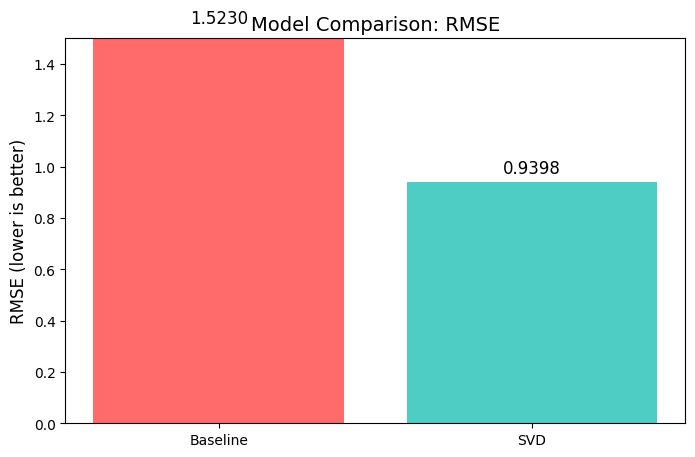


✅ Week 3 Hands-On Work Complete!


In [11]:
# =============================================
# MODEL PERFORMANCE SUMMARY
# =============================================

print("\n" + "="*60)
print("WEEK 3: COLLABORATIVE FILTERING SUMMARY")
print("="*60)

# Create a summary table
summary_data = {
    'Model': ['Popularity Baseline', 'SVD (n_factors=50)'],
    'RMSE': [round(baseline_rmse, 4), round(svd_rmse, 4)],
    'MAE': ['N/A', round(mae, 4)],
    'Precision@10': ['N/A', round(precision, 4)],
    'Recall@10': ['N/A', round(recall, 4)]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n" + "="*60)
print(f"✅ Improvement over baseline: {improvement:.2f}%")
print(f"✅ User factors: {user_factors.shape}")
print(f"✅ Item factors: {item_factors.shape}")
print("="*60)

# Create a bar chart comparing RMSE
plt.figure(figsize=(8, 5))
models = ['Baseline', 'SVD']
rmse_values = [baseline_rmse, svd_rmse]
bars = plt.bar(models, rmse_values, color=['#FF6B6B', '#4ECDC4'])
plt.title('Model Comparison: RMSE', fontsize=14)
plt.ylabel('RMSE (lower is better)', fontsize=12)
plt.ylim(0, 1.5)
for bar, value in zip(bars, rmse_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{value:.4f}', ha='center', va='bottom', fontsize=12)
plt.show()

print("\n✅ Week 3 Hands-On Work Complete!")